In [37]:
# Load Dataset
import pandas as pd


df = pd.read_csv('heart.csv')
df.drop_duplicates(inplace=True)

X = df.drop('target', axis=1)
y = df['target']

# print(X.info())
print(df['cp'].head(50))


0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    1
13    0
14    0
16    2
17    0
18    1
19    2
20    2
21    0
22    0
23    2
24    2
25    0
26    2
27    1
28    2
29    0
30    0
32    0
33    2
34    2
35    2
36    3
37    0
38    0
39    2
40    2
41    2
42    0
44    1
45    0
46    1
47    0
48    2
49    0
50    3
51    0
52    2
Name: cp, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

# Split data into 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
# ML - Model
from sklearn.tree import DecisionTreeClassifier


model = DecisionTreeClassifier(criterion="entropy", random_state=42)

In [22]:
# Best hyperparameter for decision tree

from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth' : [3, 5, 7, None],
    'min_samples_split' : [2, 5, 10, 20],
    'class_weight' : ['balanced', None]
}


grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

In [23]:
# Train model

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [24]:
predictions = grid_search.predict(X_test)

print(predictions)

[0 1 0 1 1 0 1 0 1 1 1 1 1 1 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 1 1 1 0 1 1
 1 1 1 1 1 1 1 0 0 1 0 1 0 1 1 1 0 1 1 0 1 0 0 1]


In [25]:
# GridSearch Cross-Validation Results (feat: DataFrame)

gs_report_df = pd.DataFrame(grid_search.cv_results_)
gs_report = gs_report_df[['param_class_weight', 'param_max_depth', 'param_min_samples_split', 'mean_test_score']]
gs_report = gs_report.sort_values(by="mean_test_score")

print(gs_report)

   param_class_weight param_max_depth  param_min_samples_split  \
25                NaN               7                        5   
29                NaN            None                        5   
8            balanced               7                        2   
9            balanced               7                        5   
13           balanced            None                        5   
24                NaN               7                        2   
12           balanced            None                        2   
28                NaN            None                        2   
11           balanced               7                       20   
15           balanced            None                       20   
30                NaN            None                       10   
26                NaN               7                       10   
7            balanced               5                       20   
31                NaN            None                       20   
5         

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, predictions))
print(f"\n\nConfusion Matrix\n{confusion_matrix(y_test, predictions)}")

              precision    recall  f1-score   support

           0       0.82      0.64      0.72        28
           1       0.74      0.88      0.81        33

    accuracy                           0.77        61
   macro avg       0.78      0.76      0.76        61
weighted avg       0.78      0.77      0.77        61



Confusion Matrix
[[18 10]
 [ 4 29]]


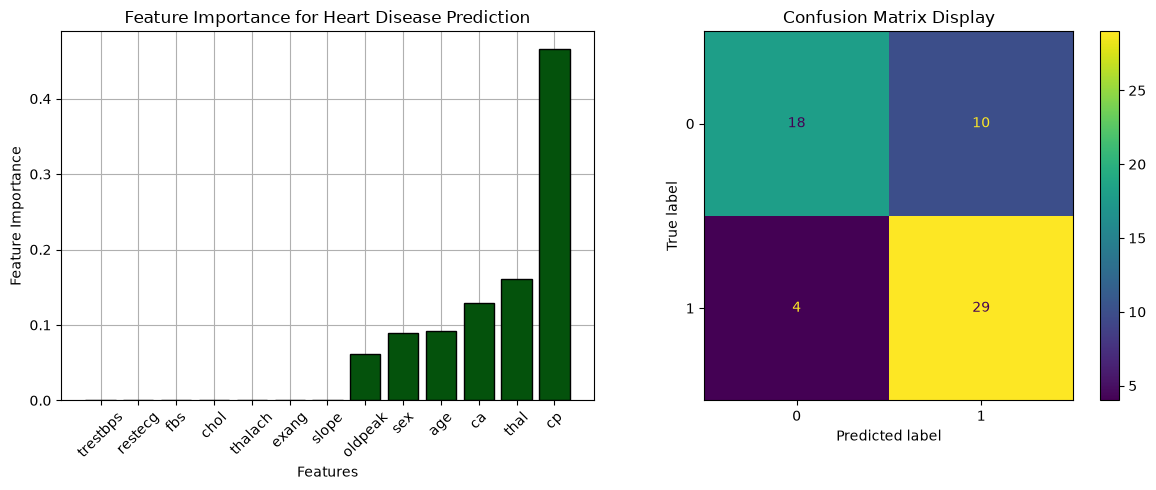

In [40]:
# Feature Importance Visualization
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1,2, figsize=(12, 5))

importances = pd.Series(
    grid_search.best_estimator_.feature_importances_,
    index=X.columns,
).sort_values()

axes[0].bar(importances.index, importances.values, color="#04520C", edgecolor="#000000")
axes[0].set_xlabel("Features")
axes[0].set_ylabel("Feature Importance")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)
axes[0].set_axisbelow(True)
axes[0].set_title("Feature Importance for Heart Disease Prediction")

ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[1])
axes[1].set_title("Confusion Matrix Display")

plt.tight_layout()
plt.show()

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=3, random_state=42)


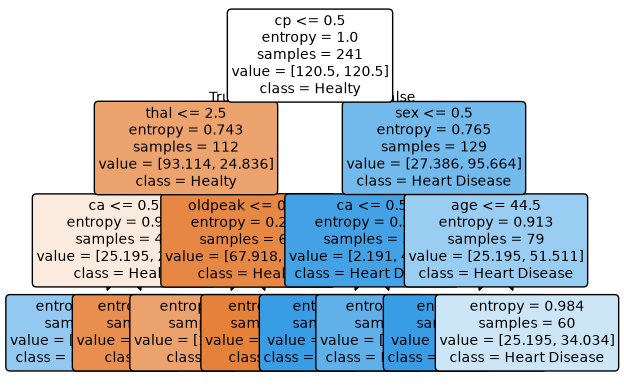

In [ ]:
# Tree Structure Visualization
from sklearn.tree import plot_tree


fig, ax = plt.subplot(figsize=(12, 5))

plot_tree(
    grid_search.best_estimator_,
    max_depth=3,
    feature_names=list(X.columns),
    class_names= ['Healty', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

print(grid_search.best_estimator_)